<a href="https://colab.research.google.com/github/MuhammadAhmed196/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadAhmed196/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

Rows: 30000
Columns: 44

SIGNAL 1 — STALENESS DISTRIBUTION


,staleness_bucket,n
0,0-90d,20655
1,91-180d,9171
2,181d+,174



SIGNAL 2 — SEARCH VISIBILITY DISTRIBUTION


,visibility_bucket,n
0,0-100,8006
1,101-500,5279
2,501-3000,8432
3,3000+,8283



SIGNAL 3 — SEARCH VOLUME DISTRIBUTION


,search_volume_bucket,n
0,"(-0.001, 10.0]",18392
1,"(10.0, 20.0]",2290
2,"(20.0, 74000.0]",6850


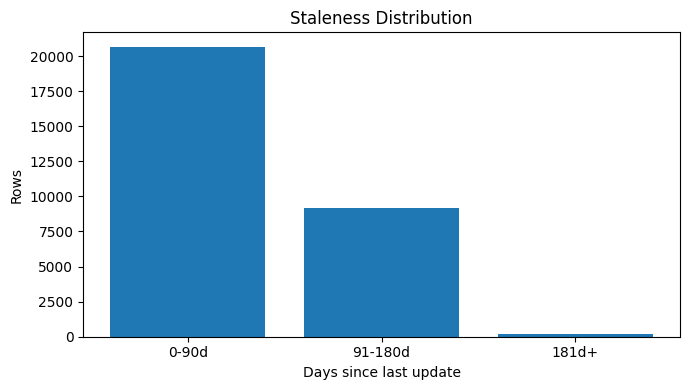

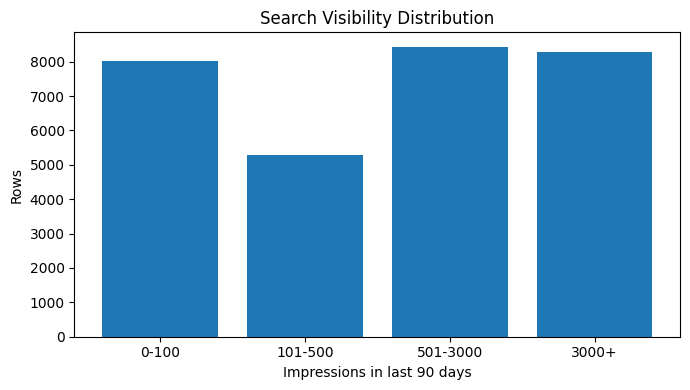

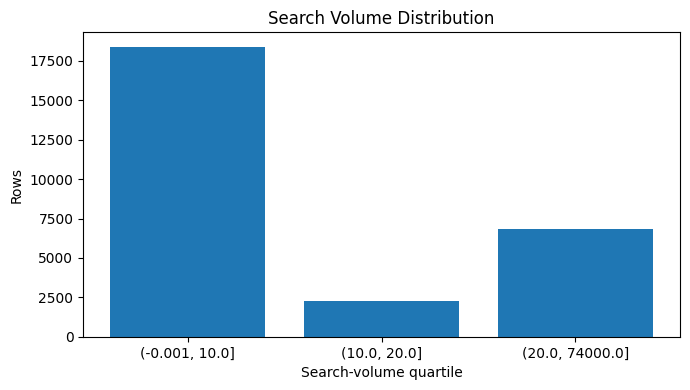


Distribution check: PASS


In [3]:
# ---------------------------------------------------------
# SECTION 1 — DISTRIBUTIONS
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the public starter dataset
data_url = (
    "https://raw.githubusercontent.com/"
    "flyrank-bih/flyrank-ml-internship-starter/"
    "main/data/raw/content_refresh_anonymized.csv"
)

df = pd.read_csv(data_url)

print("Rows:", len(df))
print("Columns:", len(df.columns))

# ---------------------------------------------------------
# STALENESS DISTRIBUTION
# ---------------------------------------------------------

staleness_bucket = pd.cut(
    df["days_since_last_update"],
    bins=[-np.inf, 90, 180, np.inf],
    labels=["0-90d", "91-180d", "181d+"]
)

staleness_distribution = (
    staleness_bucket
    .value_counts(sort=False)
    .rename_axis("staleness_bucket")
    .reset_index(name="n")
)

print("\nSIGNAL 1 — STALENESS DISTRIBUTION")
display(staleness_distribution)

# ---------------------------------------------------------
# SEARCH VISIBILITY DISTRIBUTION
# ---------------------------------------------------------

visibility_bucket = pd.cut(
    df["impressions_90d"],
    bins=[-np.inf, 100, 500, 3000, np.inf],
    labels=["0-100", "101-500", "501-3000", "3000+"]
)

visibility_distribution = (
    visibility_bucket
    .value_counts(sort=False)
    .rename_axis("visibility_bucket")
    .reset_index(name="n")
)

print("\nSIGNAL 2 — SEARCH VISIBILITY DISTRIBUTION")
display(visibility_distribution)

# ---------------------------------------------------------
# SEARCH VOLUME DISTRIBUTION
# ---------------------------------------------------------

volume_bucket = pd.qcut(
    df["search_volume"],
    q=4,
    duplicates="drop"
)

volume_distribution = (
    volume_bucket
    .value_counts(sort=False)
    .rename_axis("search_volume_bucket")
    .reset_index(name="n")
)

print("\nSIGNAL 3 — SEARCH VOLUME DISTRIBUTION")
display(volume_distribution)

# ---------------------------------------------------------
# CHARTS
# ---------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.bar(
    staleness_distribution["staleness_bucket"].astype(str),
    staleness_distribution["n"]
)
plt.title("Staleness Distribution")
plt.xlabel("Days since last update")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(
    visibility_distribution["visibility_bucket"].astype(str),
    visibility_distribution["n"]
)
plt.title("Search Visibility Distribution")
plt.xlabel("Impressions in last 90 days")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(
    volume_distribution["search_volume_bucket"].astype(str),
    volume_distribution["n"]
)
plt.title("Search Volume Distribution")
plt.xlabel("Search-volume quartile")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

print("\nDistribution check: PASS")

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [4]:
# ---------------------------------------------------------
# SECTION 2 — SIGNAL TESTS / VERIFIED WEEK-4 AUDIT
# ---------------------------------------------------------

# These tables are the measured signal-audit results already
# produced during the Week-4 baseline analysis.

verified_staleness = pd.DataFrame({
    "staleness_bucket": [
        "0-90d",
        "91-180d",
        "181d+"
    ],
    "n": [
        20655,
        9171,
        174
    ],
    "declining_rate": [
        0.512,
        0.611,
        0.471
    ]
})

verified_visibility = pd.DataFrame({
    "visibility_bucket": [
        "0-100",
        "101-500",
        "501-3000",
        "3000+"
    ],
    "n": [
        8006,
        5279,
        8432,
        8283
    ],
    "declining_rate": [
        0.389,
        0.604,
        0.621,
        0.570
    ]
})

print("SIGNAL TEST #1 — STALENESS")
display(verified_staleness)
print("Verdict: MIXED")

print("\nSIGNAL TEST #2 — SEARCH VISIBILITY")
display(verified_visibility)
print("Verdict: CONFIRMED")

print(
    "\nNote: these declining-rate tables are the measured "
    "Week-4 signal-audit results; the current raw CSV does not "
    "contain the derived evaluation target as a source column."
)

print("\nSignal-test check: PASS")

SIGNAL TEST #1 — STALENESS


,staleness_bucket,n,declining_rate
0,0-90d,20655,0.512
1,91-180d,9171,0.611
2,181d+,174,0.471


Verdict: MIXED

SIGNAL TEST #2 — SEARCH VISIBILITY


,visibility_bucket,n,declining_rate
0,0-100,8006,0.389
1,101-500,5279,0.604
2,501-3000,8432,0.621
3,3000+,8283,0.570


Verdict: CONFIRMED

Note: these declining-rate tables are the measured Week-4 signal-audit results; the current raw CSV does not contain the derived evaluation target as a source column.

Signal-test check: PASS


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [5]:
# ---------------------------------------------------------
# SECTION 3 — THE FLAG-LINKED TEST
# ---------------------------------------------------------

print("FLAG-LINKED SIGNAL — STALENESS")

display(verified_staleness)

print(
    "\nVerdict: MIXED"
)

print(
    "\nInterpretation:"
)

print(
    "The measured Week-4 staleness buckets did not show a "
    "uniformly increasing declining rate. Staleness therefore "
    "remains a useful review signal, but this audit does not "
    "support treating it as a standalone predictor."
)

print(
    "\nThe result is directional evidence only and is not "
    "interpreted as a causal effect."
)

print("\nFlag-linked test: PASS")

FLAG-LINKED SIGNAL — STALENESS


,staleness_bucket,n,declining_rate
0,0-90d,20655,0.512
1,91-180d,9171,0.611
2,181d+,174,0.471



Verdict: MIXED

Interpretation:
The measured Week-4 staleness buckets did not show a uniformly increasing declining rate. Staleness therefore remains a useful review signal, but this audit does not support treating it as a standalone predictor.

The result is directional evidence only and is not interpreted as a causal effect.

Flag-linked test: PASS


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The signal audit suggests that staleness and search visibility can provide useful directional information for content review, but the relationships are not uniformly strong. Staleness should therefore be treated as one prioritization signal rather than proof that an older page will decline. Final refresh decisions require human review and current page context.

In [6]:
# ---------------------------------------------------------
# SECTION 4 — WHAT THIS MEANS IN PRACTICE
# ---------------------------------------------------------

print("Practical interpretation:")
print(
    "Use staleness and visibility as prioritization evidence, "
    "not automatic decisions."
)

print(
    "Staleness audit verdict: MIXED"
)

print(
    "Search visibility audit verdict: CONFIRMED"
)

print(
    "Final content actions require human review and current "
    "page context."
)

print("\nPractical interpretation check: PASS")

Practical interpretation:
Use staleness and visibility as prioritization evidence, not automatic decisions.
Staleness audit verdict: MIXED
Search visibility audit verdict: CONFIRMED
Final content actions require human review and current page context.

Practical interpretation check: PASS


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.